In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, f1_score, accuracy_score, precision_score, recall_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv('../../data/processed/processed_data.csv')
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,median_bedrooms,occupancy_rate,listing_count,estimated_ltr_monthly_rent,str_rent_to_price_ratio,ltr_rent_to_price_ratio,monthly_costs,str_monthly_cash_flow,ltr_monthly_cash_flow,str_vs_ltr_cashflow_delta
0,416968,768,West Oak Hill,neighborhood,TX,TX,Austin,"Austin-Round Rock-Georgetown, TX",Travis County,225656.567739,...,2.0,42.0,61,1080.00,5.476479,2.190592,4480.002356,-1780.002356,-3400.002356,1620.00
1,271652,992,Windsor Park,neighborhood,TX,TX,Austin,"Austin-Round Rock-Georgetown, TX",Travis County,225656.567739,...,2.0,36.0,173,807.84,5.377839,2.151136,3412.506605,-1392.906605,-2604.666605,1211.76
2,275057,1156,Pleasant Valley,neighborhood,TX,TX,Austin,"Austin-Round Rock-Georgetown, TX",Travis County,116702.212787,...,2.0,0.0,39,97.92,1.103153,0.441261,2016.469971,-1771.669971,-1918.549971,146.88
3,271391,1205,Franklin Park,neighborhood,TX,TX,Austin,"Austin-Round Rock-Georgetown, TX",Travis County,76944.526694,...,3.0,36.0,14,812.16,9.083894,3.633558,2031.072669,-0.672669,-1218.912669,1218.24
4,271353,1435,Downtown,neighborhood,TX,TX,Austin,"Austin-Round Rock-Georgetown, TX",Travis County,76944.526694,...,2.0,0.0,181,2367.36,10.872523,4.349009,4946.407613,971.992387,-2579.047613,3551.04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Columns: 338 entries, RegionID to str_vs_ltr_cashflow_delta
dtypes: float64(326), int64(3), object(9)
memory usage: 148.0+ KB


In [4]:
pd.set_option("display.max_rows", None)
df.head(2).T

,0,1
RegionID,416968,271652
SizeRank,768,992
RegionName,West Oak Hill,Windsor Park
RegionType,neighborhood,neighborhood
StateName,TX,TX
State,TX,TX
City,Austin,Austin
Metro,"Austin-Round Rock-Georgetown, TX","Austin-Round Rock-Georgetown, TX"
CountyName,Travis County,Travis County
2000-01-31,225656.567739,225656.567739


In [5]:
df.dtypes.T

RegionID                        int64
SizeRank                        int64
RegionName                     object
RegionType                     object
StateName                      object
State                          object
City                           object
Metro                          object
CountyName                     object
2000-01-31                    float64
2000-02-29                    float64
2000-03-31                    float64
2000-04-30                    float64
2000-05-31                    float64
2000-06-30                    float64
2000-07-31                    float64
2000-08-31                    float64
2000-09-30                    float64
2000-10-31                    float64
2000-11-30                    float64
2000-12-31                    float64
2001-01-31                    float64
2001-02-28                    float64
2001-03-31                    float64
2001-04-30                    float64
2001-05-31                    float64
2001-06-30  

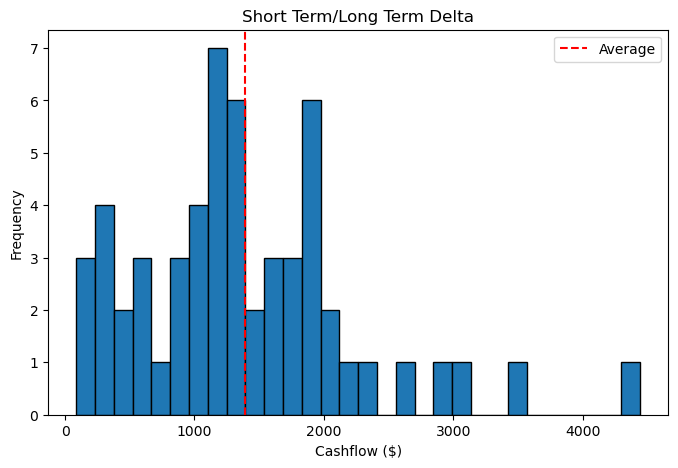

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df['str_vs_ltr_cashflow_delta'], edgecolor='black', bins=30)
plt.axvline(df['str_vs_ltr_cashflow_delta'].mean(), label='Average', color='red', linestyle='--')
plt.title('Short Term/Long Term Delta')
plt.xlabel('Cashflow ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [7]:
walkers = {
    "Dad": [42, 'male'],
    "Clebo": [16, 'male'],
    "Liam": [14, 'male'],
    "Henry": [11, 'male']
}

walkers["Delta"] = [21, 'female']
walkers["Brooke"] = [20, 'female']

age = [age for name, (age, gender) in walkers.items()]
name = [name for name, (age, gender) in walkers.items()]
gender = [gender for name, (age, gender) in walkers.items()]
print(age)
print(name)
print(gender)

print(f"\nThe Walkers range in age from {min(age)} to {max(age)}")
print(f"\nThe family has {gender.count('male')} boys and {gender.count('female')} girls")
print(f"\nTheir names are {name}")

[42, 16, 14, 11, 21, 20]
['Dad', 'Clebo', 'Liam', 'Henry', 'Delta', 'Brooke']
['male', 'male', 'male', 'male', 'female', 'female']

The Walkers range in age from 11 to 42

The family has 4 boys and 2 girls

Their names are ['Dad', 'Clebo', 'Liam', 'Henry', 'Delta', 'Brooke']


In [8]:
drivers = [name for name, (age, gender) in walkers.items() if age >=16]
print(drivers)

['Dad', 'Clebo', 'Delta', 'Brooke']


In [9]:
print(f"Age gap: {max(age) - min(age)} years\nAverage Age: {sum(age)//len(age)}")

Age gap: 31 years
Average Age: 20


In [10]:
print(df['RegionName'].nunique())
df['RegionName'].value_counts()

56


RegionName
West Oak Hill          1
Windsor Park           1
Rosewood               1
Hancock                1
MLK                    1
Mckinney               1
Galindo                1
Rosedale               1
University Hills       1
North University       1
North Shoal Creek      1
Old West Austin        1
Westgate               1
East Cesar Chavez      1
East Congress          1
West Congress          1
Coronado Hills         1
Dawson                 1
Holly                  1
Barton Creek           1
Chestnut               1
Bryker Woods           1
Old Enfield            1
Johnston Terrace       1
Fern Bluff             1
Brushy Bend Park       1
Kensington Place       1
Upper Boggy Creek      1
North Loop             1
Highland               1
Georgian Acres         1
Pleasant Valley        1
Franklin Park          1
Downtown               1
Allandale              1
Montopolis             1
North Burnet           1
Brentwood              1
St. Johns              1
Zilker        

In [11]:
df.nlargest(5, 'listing_count')[['RegionName', 'listing_count']]

,RegionName,listing_count
10,Zilker,407
15,South Lamar,309
46,Holly,294
22,Bouldin Creek,249
11,Barton Hills,232


In [12]:
df.sort_values('listing_count', ascending=False).head(5)[['RegionName', 'listing_count']]

,RegionName,listing_count
10,Zilker,407
15,South Lamar,309
46,Holly,294
22,Bouldin Creek,249
11,Barton Hills,232


In [13]:
neighborhood_count = df['RegionName'].nunique()
print(f"Total unique neighborhoods: {neighborhood_count}")

print("\nTop 5 neighborhoods by listing count:")
top_5 = df.nlargest(5, 'listing_count')[['RegionName', 'listing_count']]
print(top_5)

Total unique neighborhoods: 56

Top 5 neighborhoods by listing count:
       RegionName  listing_count
10         Zilker            407
15    South Lamar            309
46          Holly            294
22  Bouldin Creek            249
11   Barton Hills            232
